In [1]:
from qiskit import QuantumCircuit

# Create a simple 2-qubit circuit
qc = QuantumCircuit(2)

# Add a Hadamard gate on qubit 0 (creates superposition)
qc.h(0)

# Add a CNOT gate (entangles the two qubits)
qc.cx(0, 1)

# Visualize the circuit
print(qc.draw())

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘


In [2]:
! pip install matplotlib pylatexenc > NUL

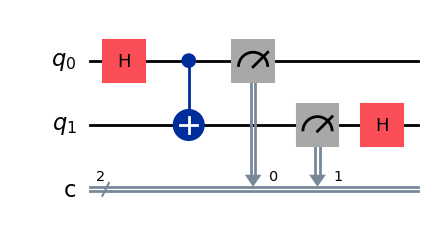

In [3]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler


qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.h(1)
qc.draw('mpl')


In [ ]:
from qiskit_aer import AerSimulator


simulator = AerSimulator()

# Transpile and run
from qiskit import transpile

compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()

counts = result.get_counts()
print(counts)  # e.g., {'00': 512, '11': 512}

{'11': 516, '00': 508}


In [5]:
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
qc_no_measure = QuantumCircuit(2)
qc_no_measure.h(0)
qc_no_measure.cx(0, 1)

sv = Statevector(qc_no_measure)
print(sv)  # Shows the full quantum state vector
sv.draw('latex')

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


<IPython.core.display.Latex object>

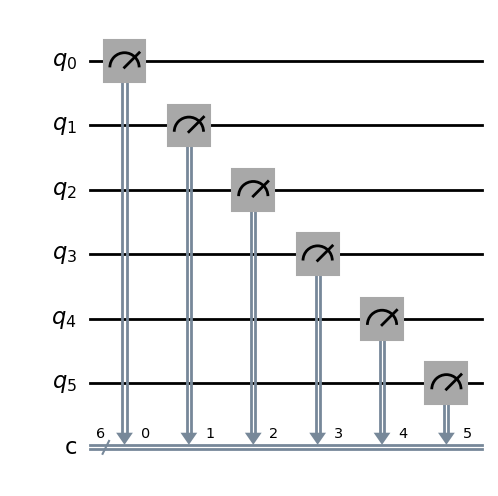

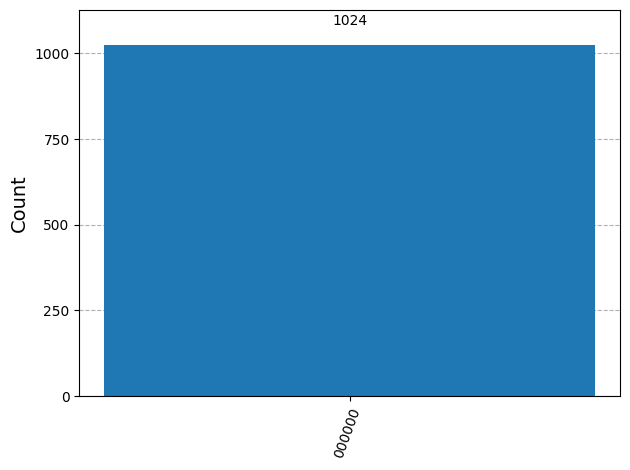

In [7]:
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector



qc = QuantumCircuit(6,6)

# add measurements so the simulator produces counts
qc.measure([0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5])

qc.draw('mpl')

simulator = AerSimulator()

# Transpile and run
from qiskit import transpile

compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()

counts = result.get_counts()

display(qc.draw('mpl'))
display(plot_histogram(counts))

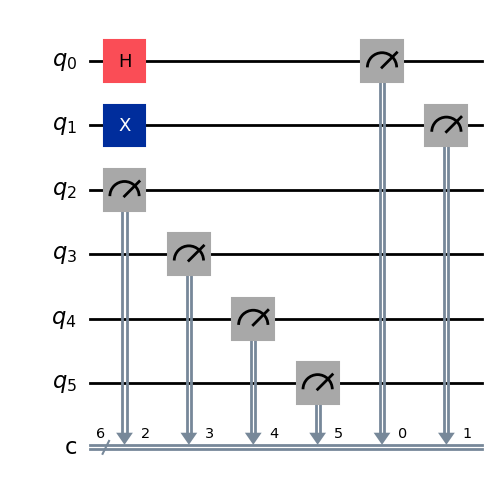

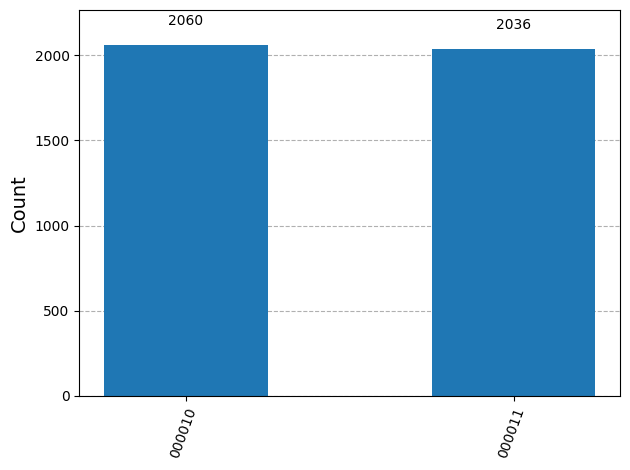

In [8]:
def present_run(qc):

    simulator = AerSimulator()

    # Transpile and run
    from qiskit import transpile

    compiled = transpile(qc, simulator)
    job = simulator.run(compiled, shots=2**12)
    result = job.result()

    counts = result.get_counts()

    display(qc.draw('mpl'))
    display(plot_histogram(counts))

qc = QuantumCircuit(6, 6)
qc.h(0)
qc.x(1)

qc.measure([0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5])
present_run(qc)

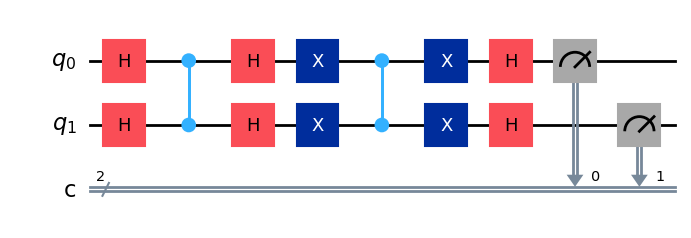

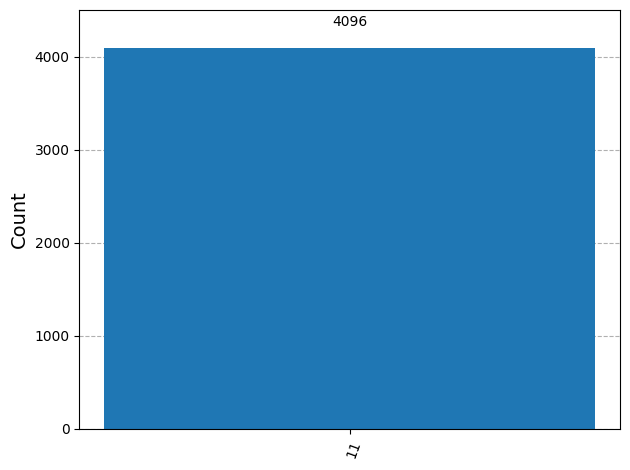

In [18]:

manual_qc = QuantumCircuit(2,2)
# 1: Hadamard gate to create superposition
manual_qc.h([0, 1])

# 2: Oracle
# CZ flips the phase of |11> only, |11> is target state
manual_qc.cz(0, 1)

# 3: Diffusion operator (reflection about the mean?)
# H on all qubits
manual_qc.h([0, 1])
# X on all qubits
manual_qc.x([0, 1])
# Multi-controlled Z (for 2 qubits)
manual_qc.cz(0, 1)
# X on all qubits
manual_qc.x([0, 1])
# H on all qubits
manual_qc.h([0, 1])



manual_qc.measure([0, 1], [0, 1])
present_run(manual_qc)

